## CRAG를 활용한 서비스 구현

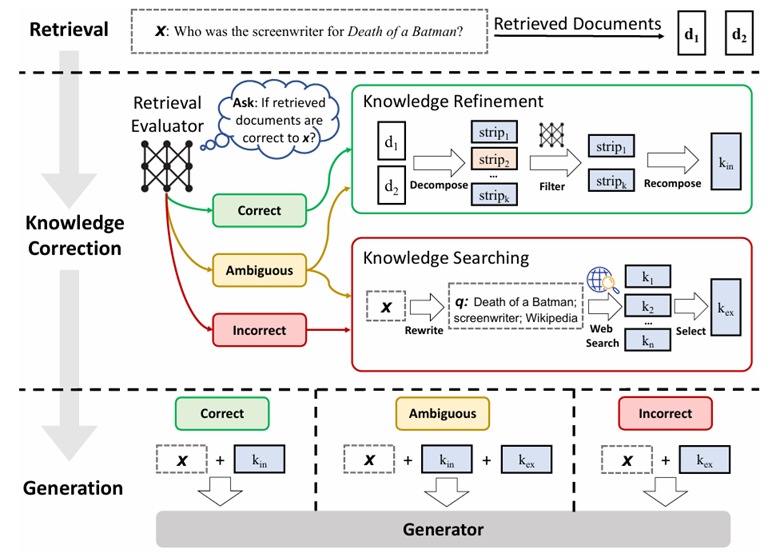


[논문(Corrective Retrieval Augmented Generation) 링크](https://arxiv.org/pdf/2401.15884.pdf)

**참고**

- [LangGraph CRAG 튜토리얼 (공식 문서)](https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_crag_local/)

### 환경 설정



In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv()

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("CH17-LangGraph-Use-Cases")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH17-LangGraph-Use-Cases


### Gemini PDF Loader 테스트

In [3]:
from google import genai
from google.genai import types
import pathlib
import httpx


def gemini_document_loader(file_path: str):

    client = genai.Client()

    # Retrieve and encode the PDF byte
    file_path = pathlib.Path(file_path)

    # Upload the PDF using the File API
    sample_file = client.files.upload(
        file=file_path,
    )

    prompt = """당신은 PDF 문서 분석 전문가입니다.
                주어진 PDF 파일의 각 페이지를 순서대로 분석하여, 페이지별로 내용을 구분해서 추출해주세요.

                출력 형식:
                [PAGE 1]
                (1페이지의 텍스트 내용)

                [PAGE 2]
                (2페이지의 텍스트 내용)

                ... (이런 식으로 계속)

                각 페이지에서:
                - 텍스트와 표(table) 형식의 데이터를 모두 추출
                - 차트나 이미지에 대한 설명은 제외
                - 순수 텍스트와 표의 내용만 정확하게 추출

                반드시 [PAGE N] 마커로 각 페이지를 구분해주세요.
                """

    response = client.models.generate_content(
        model="gemini-2.5-flash", contents=[sample_file, prompt]
    )
    return response

In [4]:
response = gemini_document_loader("data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf")

In [5]:
response.text

"[PAGE 1]\nSPRi Al Brief |\n2023-12월호\n삼성전자, 자체 개발 생성 AI '삼성 가우스' 공개\nKEY Contents\n■ 삼성전자가 온디바이스에서 작동 가능하며 언어, 코드, 이미지의 3개 모델로 구성된 자체 개발 생성\nAI 모델 '삼성 가우스'를 공개\n■ 삼성전자는 삼성 가우스를 다양한 제품에 단계적으로 탑재할 계획으로, 온디바이스 작동이 가능한\n삼성 가우스는 외부로 사용자 정보가 유출될 위험이 없다는 장점을 보유\n● 언어, 코드, 이미지의 3개 모델로 구성된 삼성 가우스, 온디바이스 작동 지원\n■ 삼성전자가 2023년 11월 8일 열린 ‘삼성 AI 포럼 2023’행사에서 자체 개발한 생성 AI 모델\n‘삼성 가우스'를 최초 공개\n• 정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본뜬 삼성 가우스는 다양한 상황에\n최적화된 크기의 모델 선택이 가능\n• 삼성 가우스는 라이선스나 개인정보를 침해하지 않는 안전한 데이터를 통해 학습되었으며,\n온디바이스에서 작동하도록 설계되어 외부로 사용자의 정보가 유출되지 않는 장점을 보유\n• 삼성전자는 삼성 가우스를 활용한 온디바이스 AI 기술도 소개했으며, 생성 AI 모델을 다양한 제품에\n단계적으로 탑재할 계획\n■ 삼성 가우스는 △텍스트를 생성하는 언어모델 △코드를 생성하는 코드 모델 △이미지를 생성하는\n이미지 모델의 3개 모델로 구성\n• 언어 모델은 클라우드와 온디바이스 대상 다양한 모델로 구성되며, 메일 작성, 문서 요약, 번역 업무의\n처리를 지원\n• 코드 모델 기반의 AI 코딩 어시스턴트 ‘코드아이(code.i)'는 대화형 인터페이스로 서비스를 제공하며\n사내 소프트웨어 개발에 최적화\n• 이미지 모델은 창의적인 이미지를 생성하고 기존 이미지를 원하는 대로 바꿀 수 있도록 지원하며\n저해상도 이미지의 고해상도 전환도 지원\n■ IT 전문지 테크리퍼블릭(TechRepublic)은 온디바이스 AI가 주요 기술 트렌드로 부상했다며,\n2024년부터 가

### 위의 코드를 바탕으로 gemini_pdf.py파일 생성하기

### gemini_pdf.py파일을 사용하여 테스트

In [6]:
from rag.gemini_pdf import GeminiPDFRetrievalChain

# PDF 문서를 로드
pdf = GeminiPDFRetrievalChain(
    ["data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf"]
).create_chain()

Gemini로 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf' 파일 처리 시작...
✅ 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf' 파일 처리 완료.
'SPRI_AI_Brief_2023년12월호_F_13-15.pdf' 원격 파일 삭제 완료.


### document가 잘 생성되는지 확인

In [7]:
docs = pdf.get_docs()
for i, doc in enumerate(docs[:3]):
    print(docs[i])
    print("\n---\n")

page_content='SPRi Al Brief |
2023-12월호
삼성전자, 자체 개발 생성 AI '삼성 가우스' 공개
KEY Contents
■ 삼성전자가 온디바이스에서 작동 가능하며 언어, 코드, 이미지의 3개 모델로 구성된 자체 개발 생성
AI 모델 '삼성 가우스'를 공개
■ 삼성전자는 삼성 가우스를 다양한 제품에 단계적으로 탑재할 계획으로, 온디바이스 작동이 가능한
삼성 가우스는 외부로 사용자 정보가 유출될 위험이 없다는 장점을 보유
● 언어, 코드, 이미지의 3개 모델로 구성된 삼성 가우스, 온디바이스 작동 지원
■ 삼성전자가 2023년 11월 8일 열린 ‘삼성 AI 포럼 2023’행사에서 자체 개발한 생성 AI 모델
‘삼성 가우스'를 최초 공개
• 정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본뜬 삼성 가우스는 다양한 상황에
최적화된 크기의 모델 선택이 가능
• 삼성 가우스는 라이선스나 개인정보를 침해하지 않는 안전한 데이터를 통해 학습되었으며,
온디바이스에서 작동하도록 설계되어 외부로 사용자의 정보가 유출되지 않는 장점을 보유
• 삼성전자는 삼성 가우스를 활용한 온디바이스 AI 기술도 소개했으며, 생성 AI 모델을 다양한 제품에
단계적으로 탑재할 계획
■ 삼성 가우스는 △텍스트를 생성하는 언어모델 △코드를 생성하는 코드 모델 △이미지를 생성하는
이미지 모델의 3개 모델로 구성
• 언어 모델은 클라우드와 온디바이스 대상 다양한 모델로 구성되며, 메일 작성, 문서 요약, 번역 업무의
처리를 지원
• 코드 모델 기반의 AI 코딩 어시스턴트 ‘코드아이(code.i)'는 대화형 인터페이스로 서비스를 제공하며
사내 소프트웨어 개발에 최적화
• 이미지 모델은 창의적인 이미지를 생성하고 기존 이미지를 원하는 대로 바꿀 수 있도록 지원하며
저해상도 이미지의 고해상도 전환도 지원
■ IT 전문지 테크리퍼블릭(TechRepublic)은 온디바이스 AI가 주요 기술 트렌드로 부상했다며,
2024년부터 가우스를 탑재한 삼성 스마트폰이 메타의 라마

In [3]:
from rag.gemini_pdf import GeminiPDFRetrievalChain

# PDF 문서를 로드
pdf = GeminiPDFRetrievalChain(
    ["data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf"]
).create_chain()

# retriever 와 chain을 생성
pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

Gemini로 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf' 파일 처리 시작...
✅ 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf' 파일 처리 완료.
'SPRI_AI_Brief_2023년12월호_F_13-15.pdf' 원격 파일 삭제 완료.


### **새로 추가한 GeminiPDFRetrievalChain의 테스트**

In [4]:
docs = pdf.get_docs()
for i, doc in enumerate(docs[:3]):
    print(docs[i])

AttributeError: 'GeminiPDFRetrievalChain' object has no attribute 'docs'

**1. get_split_docs()메소드를 추가하여 확인**

In [ ]:
split_docs = pdf.get_split_docs()
for i, doc in enumerate(split_docs[:3]):
    print(split_docs[i].page_content)

**2. pdf_retriever 테스트**

In [5]:
pdf_retriever.get_relevant_documents("삼성전자에서 만든 인공지능 모델의 이름은?")[:5]

C:\Users\SBA\AppData\Local\Temp\ipykernel_18812\2779833326.py:1: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  pdf_retriever.get_relevant_documents("삼성전자에서 만든 인공지능 모델의 이름은?")[:5]


[Document(id='448d8c66-c684-4e4c-b8bb-0ee03789332f', metadata={'source': 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf', 'page': 1}, page_content="● 언어, 코드, 이미지의 3개 모델로 구성된 삼성 가우스, 온디바이스 작동 지원\n■ 삼성전자가 2023년 11월 8일 열린 ‘삼성 AI 포럼 2023’행사에서 자체 개발한 생성 AI 모델\n‘삼성 가우스'를 최초 공개\n• 정규분포 이론을 정립한 천재 수학자 가우스(Gauss)의 이름을 본뜬 삼성 가우스는 다양한 상황에\n최적화된 크기의 모델 선택이 가능\n• 삼성 가우스는 라이선스나 개인정보를 침해하지 않는 안전한 데이터를 통해 학습되었으며,\n온디바이스에서 작동하도록 설계되어 외부로 사용자의 정보가 유출되지 않는 장점을 보유"),
 Document(id='017d381c-3634-4d1c-bdf9-473d928fb7b5', metadata={'source': 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf', 'page': 1}, page_content="처리를 지원\n• 코드 모델 기반의 AI 코딩 어시스턴트 ‘코드아이(code.i)'는 대화형 인터페이스로 서비스를 제공하며\n사내 소프트웨어 개발에 최적화\n• 이미지 모델은 창의적인 이미지를 생성하고 기존 이미지를 원하는 대로 바꿀 수 있도록 지원하며\n저해상도 이미지의 고해상도 전환도 지원\n■ IT 전문지 테크리퍼블릭(TechRepublic)은 온디바이스 AI가 주요 기술 트렌드로 부상했다며,\n2024년부터 가우스를 탑재한 삼성 스마트폰이 메타의 라마(Llama)2를 탑재한 퀄컴 기기 및 구글"),
 Document(id='8a030613-99f6-4760-a5f8-01e8a396e55c', metadata={'source': 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf', 'page':

## 검색된 문서의 관련성 평가 (Question-Retrieval Evaluation)

검색된 문서의 관련성 평가는 검색된 문서가 질문과 관련이 있는지 여부를 평가하는 단계입니다.

먼저, 검색된 문서를 평가하기 위한 평가기(`retrieval-grader`) 를 생성합니다.

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_teddynote.models import get_model_name, LLMs
from pydantic import BaseModel, Field

# 모델 이름 가져오기
MODEL_NAME = get_model_name(LLMs.GPT4)


# 검색된 문서의 관련성 여부를 이진 점수로 평가하는 데이터 모델
class GradeDocuments(BaseModel):
    """A binary score to determine the relevance of the retrieved document."""

    # 문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no'로 나타내는 필드
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM 초기화
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

# GradeDocuments 데이터 모델을 사용하여 구조화된 출력을 생성하는 LLM
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 시스템 프롬프트 정의
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

# 채팅 프롬프트 템플릿 생성
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

# Retrieval 평가기 초기화
retrieval_grader = grade_prompt | structured_llm_grader

`retrieval_grader` 를 사용해서 문서를 평가합니다. 

여기서는 문서의 집합이 아닌 1개의 단일 문서에 대한 평가를 수행합니다.

결과는 단일 문서에 대한 관련성 여부가 (yes/no) 로 반환됩니다.

In [7]:
# 질문 정의
question = "삼성전자가 개발한 생성AI 에 대해 설명하세요."

# 문서 검색
docs = pdf_retriever.invoke(question)

# 검색된 문서 중 1번 index 문서의 페이지 내용을 추출
doc_txt = docs[1].page_content

# 검색된 문서와 질문을 사용하여 관련성 평가를 실행하고 결과 출력
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

binary_score='yes'


## 답변 생성 체인

답변 생성 체인은 검색된 문서를 기반으로 답변을 생성하는 체인입니다.

우리가 알고 있는 일반적인 Naive RAG 체인 입니다.

In [8]:
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI


# LangChain Hub에서 RAG 프롬프트를 가져와 사용
prompt = hub.pull("teddynote/rag-prompt")

# LLM 초기화
llm = ChatOpenAI(model_name=MODEL_NAME, temperature=0)


# 문서 포맷팅
def format_docs(docs):
    return "\n\n".join(
        [
            f'<document><content>{doc.page_content}</content><source>{doc.metadata["source"]}</source><page>{doc.metadata["page"]+1}</page></document>'
            for doc in docs
        ]
    )


# 체인 생성
rag_chain = prompt | llm | StrOutputParser()


# 체인 실행 및 결과 출력
generation = rag_chain.invoke({"context": format_docs(docs), "question": question})
print(generation)

삼성전자가 개발한 생성 AI '삼성 가우스'는 온디바이스에서 작동 가능하며, 언어, 코드, 이미지의 3개 모델로 구성되어 있습니다. 이 AI 모델은 외부로 사용자 정보가 유출될 위험이 없다는 장점을 가지고 있으며, 다양한 제품에 단계적으로 탑재될 계획입니다. '삼성 가우스'는 2023년 11월 8일 '삼성 AI 포럼 2023'에서 최초 공개되었습니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf (page 2)


## 쿼리 재작성(Question Re-writer)

쿼리 재작성은 웹 검색을 최적화하기 위해 질문을 재작성하는 단계입니다.

In [9]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# LLM 설정
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)

# Query Rewrite 시스템 프롬프트
system = """You a question re-writer that converts an input question to a better version that is optimized 
for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

# 프롬프트 정의
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

# Question Re-writer 체인 초기화
question_rewriter = re_write_prompt | llm | StrOutputParser()

`question_rewriter` 를 사용해서 질문을 재작성합니다.

In [10]:
# 실행 및 결과 확인
print(f'[원본 질문]: "{question}"')
print("[쿼리 재작성]:", question_rewriter.invoke({"question": question}))

[원본 질문]: "삼성전자가 개발한 생성AI 에 대해 설명하세요."
[쿼리 재작성]: 삼성전자가 개발한 생성 AI의 특징과 기능은 무엇인가요?


## 웹 검색 도구

**웹 검색 도구**는 컨텍스트를 보강하기 위한 용도로 사용됩니다.

- **웹 검색의 필요성**: 모든 문서가 관련성 임계값을 충족하지 않거나 평가자가 확신이 없을 때, 웹 검색을 통해 추가 데이터를 확보합니다.
- **Tavily Search 사용**: Tavily Search를 활용하여 웹 검색을 수행합니다. 이는 검색 쿼리를 최적화하고, 보다 관련성 높은 결과를 제공합니다.
- **질문 재작성**: 웹 검색을 최적화하기 위해 질문을 재작성하여 검색 쿼리를 개선합니다.

In [11]:
# 웹 검색 도구 초기화
from langchain_teddynote.tools.tavily import TavilySearch

# 최대 검색 결과를 3으로 설정
web_search_tool = TavilySearch(max_results=3)

In [12]:
# 웹 검색 도구 실행
results = web_search_tool.invoke({"query": question})
print(results)

[{'url': 'https://www.aitimes.kr/news/articleView.html?idxno=29318', 'title': "삼성전자, 생성 AI 모델 '삼성 가우스' 공개...언어‧코드‧이미지 3개 모델 ...", 'content': "삼성전자가 8일, 삼성전자 서울R&D캠퍼스에서 열린 '삼성 AI 포럼 2023'을 통해\xa0생성 AI 모델 '삼성 가우스(Samsung Gauss)'를 최초 공개했다. 삼성리서치에서 개발한 이 모델 '삼성 가우스''는 정규분포 이론을 정립한 천재 수학자 칼 프리드리히 가우스(Carl Friedrich Gauss)로부터 영감을 얻은 생성형 AI 모델로, 삼성이 추구하는 생성형 AI의 무한한 가능성을 의미한다. 또한, 코드 모델을 기반으로 개발된 AI 코딩 어시스턴트 '코드아이(code.i)'는 사내 소프트웨어 개발에 최적화되어 개발자들이 쉽고 빠르게 코딩할 수 있도록 도와준다. 또 LLM의 특징과 앞으로의 발전 방향(오픈AI 정형원), '멀티 모달(Multi-modal) 대화형 AI'(고려대 서홍석 교수)\xa0, 생성형 AI 활용한 효율적인 코드 생성 기술(서울대 황승원 교수 연구실), 고밀도 2D-3D 실내 예측(서울대 김건희 교수 연구실), 언어 모델 평가 방법(KAIST 서민준 교수 연구실), 긴 맥락을 이해해 영상을 생성하는 '텍스트 투 이미지(Text-to-image)' 생성 기술(연세대 최종현 교수 연구실) 등\xa0생성형 AI의 현황과 향후 연구 방향에 대해서 공유했다.", 'score': 0.829285, 'raw_content': '## 상단영역\n\n\n\n\n## 본문영역\n\n### 삼성전자, 생성 AI 모델 \'삼성 가우스\' 공개...언어‧코드‧이미지 3개 모델, "생산성 향상과 새로운 사용자 경험 제공할 것!"\n\n* *기자명*\n  전미준 기자\n* 입력 2023.11.08 10:30\n* 댓글 0\n\n\n\n#### ‘언어 모델’은 메일 작성, 문서 요약, 번역 등 업무를 더

## 상태(State)

먼저, CRAG 그래프를 위한 상태를 정의합니다.

`web_search` 는 웹 검색을 활용할지 여부를 나타내는 상태입니다. yes 또는 no 로 표현합니다 (yes: 웹 검색 필요, no: 필요 없음)

In [13]:
from typing import Annotated, List
from typing_extensions import TypedDict


# 상태 정의
class GraphState(TypedDict):
    question: Annotated[str, "The question to answer"]
    generation: Annotated[str, "The generation from the LLM"]
    web_search: Annotated[str, "Whether to add search"]
    documents: Annotated[List[str], "The documents retrieved"]

## 노드

CRAG 그래프에 활용할 노드를 정의합니다.

In [14]:
from langchain.schema import Document


# 문서 검색 노드
def retrieve(state: GraphState):
    print("\n==== RETRIEVE ====\n")
    question = state["question"]

    # 문서 검색 수행
    documents = pdf_retriever.invoke(question)
    return {"documents": documents}


# 답변 생성 노드
def generate(state: GraphState):
    print("\n==== GENERATE ====\n")
    question = state["question"]
    documents = state["documents"]

    # RAG를 사용한 답변 생성
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"generation": generation}


# 문서 평가 노드
def grade_documents(state: GraphState):
    print("\n==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====\n")
    question = state["question"]
    documents = state["documents"]

    # 필터링된 문서
    filtered_docs = []
    relevant_doc_count = 0

    for d in documents:
        # Question-Document 의 관련성 평가
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score

        if grade == "yes":
            print("==== [GRADE: DOCUMENT RELEVANT] ====")
            # 관련 있는 문서를 filtered_docs 에 추가
            filtered_docs.append(d)
            relevant_doc_count += 1
        else:
            print("==== [GRADE: DOCUMENT NOT RELEVANT] ====")
            continue

    # 관련 문서가 없으면 웹 검색 수행
    web_search = "Yes" if relevant_doc_count == 0 else "No"
    return {"documents": filtered_docs, "web_search": web_search}


# 쿼리 재작성 노드
def query_rewrite(state: GraphState):
    print("\n==== [REWRITE QUERY] ====\n")
    question = state["question"]

    # 질문 재작성
    better_question = question_rewriter.invoke({"question": question})
    return {"question": better_question}


# 웹 검색 노드
def web_search(state: GraphState):
    print("\n==== [WEB SEARCH] ====\n")
    question = state["question"]
    documents = state["documents"]

    # 웹 검색 수행
    docs = web_search_tool.invoke({"query": question})
    # 검색 결과를 문서 형식으로 변환
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents}

## 조건부 엣지에 활용할 함수

`decide_to_generate` 함수는 관련성 평가를 마친 뒤, 웹 검색 여부에 따라 다음 노드로 라우팅하는 역할을 수행합니다.

`web_search` 가 `Yes` 인 경우 `query_rewrite` 노드에서 쿼리를 재작성 한 뒤 웹 검색을 수행합니다.

만약, `web_search` 가 `No` 인 경우는 `generate` 를 수행하여 최종 답변을 생성합니다.

In [15]:
def decide_to_generate(state: GraphState):
    # 평가된 문서를 기반으로 다음 단계 결정
    print("==== [ASSESS GRADED DOCUMENTS] ====")
    # 웹 검색 필요 여부
    web_search = state["web_search"]

    if web_search == "Yes":
        # 웹 검색으로 정보 보강이 필요한 경우
        print(
            "==== [DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, QUERY REWRITE] ===="
        )
        # 쿼리 재작성 노드로 라우팅
        return "query_rewrite"
    else:
        # 관련 문서가 존재하므로 답변 생성 단계(generate) 로 진행
        print("==== [DECISION: GENERATE] ====")
        return "generate"

## 그래프 생성

이제 노드를 정의하고 엣지를 연결하여 그래프를 완성합니다.

In [16]:
from langgraph.graph import END, StateGraph, START

# 그래프 상태 초기화
workflow = StateGraph(GraphState)

# 노드 정의
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("query_rewrite", query_rewrite)
workflow.add_node("web_search_node", web_search)

# 엣지 연결
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")

# 문서 평가 노드에서 조건부 엣지 추가
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "query_rewrite": "query_rewrite",
        "generate": "generate",
    },
)

# 엣지 연결
workflow.add_edge("query_rewrite", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# 그래프 컴파일
app = workflow.compile()

그래프를 시각화합니다.

In [17]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(app)

그래프 시각화 실패 (추가 종속성 필요): Failed to reach https://mermaid.ink/ API while trying to render your graph. Status code: 502.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`
ASCII로 그래프 표시:
                +-----------+         
                | __start__ |         
                +-----------+         
                       *              
                       *              
                       *              
                 +----------+         
                 | retrieve |         
                 +----------+         
                       *              
                       *              
                       *              
              +-----------------+     
              | grade_documents |     
    

## 그래프 실행

이제 그래프를 실행하고 결과를 확인합니다.

In [18]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph, invoke_graph, random_uuid

# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

# 질문 입력
inputs = {
    "question": "삼성전자가 개발한 생성형 AI 의 이름은?",
}

# 스트리밍 형식으로 그래프 실행
stream_graph(
    app,
    inputs,
    config,
    ["retrieve", "grade_documents", "query_rewrite", "web_search_node", "generate"],
)


==== RETRIEVE ====


==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====


🔄 Node: grade_documents 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"binary_score":"yes"}==== [GRADE: DOCUMENT RELEVANT] ====
{"binary_score":"yes"}==== [GRADE: DOCUMENT RELEVANT] ====
{"binary_score":"yes"}==== [GRADE: DOCUMENT RELEVANT] ====
{"binary_score":"yes"}==== [GRADE: DOCUMENT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [ASSESS GRADED DOCUMENTS] ====
==== [DECISION: GENERATE] ====

==== GENERATE ====


🔄 Node: generate 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
삼성전자가 개발한 생성형 AI의 이름은 '삼성 가우스'입니다.

**Source**
- data/SPRI_AI_Brief_2023년12월호_F_13-

In [19]:
# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

# 질문 입력
inputs = {
    "question": "2024년 노벨문학상 수상자의 이름은?",
}

그래프를 실행합니다.

In [20]:
# 그래프 실행
invoke_graph(app, inputs, config)


==== RETRIEVE ====


🔄 Node: retrieve 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
page_content='어시스턴트를 적용한 구글 픽셀(Pixel)과 경쟁할 것으로 예상
출처: 삼성전자, '삼성 AI 포럼'서 자체 개발 생성형 AI '삼성 가우스' 공개, 2023.11.08.
삼성전자, '삼성 개발자 콘퍼런스 코리아 2023' 개최, 2023.11.14.
TechRepublic, Samsung Gauss: Samsung Research Reveals Generative Al, 2023.11.08.
10' metadata={'source': 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf', 'page': 1}
page_content='4년간 30억 달러 규모의 계약을 체결
• 오픈AI 창업자 그룹의 일원이었던 다리오(Dario Amodei)와 다니엘라 아모데이(Daniela Amodei)
남매가 2021년 설립한 앤스로픽은 챗GPT의 대항마 ‘클로드(Claude)' LLM을 개발
■ 아마존과 구글의 앤스로픽 투자에 앞서, 마이크로소프트는 차세대 AI 모델의 대표 주자인 오픈
AI와 협력을 확대
• 마이크로소프트는 오픈AI에 앞서 투자한 30억 달러에 더해 2023년 1월 추가로 100억 달러를' metadata={'source': 'data/SPRI_AI_Brief_2023년12월호_F_13-15.pdf', 'page': 2}
page_content='1. 정책/법제
2. 기업/산업
3. 기술/연구
4. 인력/교육
구글, 앤스로픽에 20억 달러 투자로 생성 AI 협력 강화
KEY Contents
■ 구글이 앤스로픽에 최대 20억 달러 투자에 합의하고 5억 달러를 우선 투자했으며, 앤스로픽은
구글과 클라우드 서비스 사용 계약도 체결
■ 3대 클라우드 사업자인 구글, 마이크로소프트, 아마존은 차세대 AI 모델의 대표 기업인
앤스로픽 및 오픈AI와 협력을 

스트리밍 형식으로 그래프를 실행합니다.

In [21]:
# 그래프 실행
stream_graph(
    app,
    inputs,
    config,
    ["retrieve", "grade_documents", "query_rewrite", "generate"],
)


==== RETRIEVE ====


==== [CHECK DOCUMENT RELEVANCE TO QUESTION] ====


🔄 Node: grade_documents 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
{"binary_score":"no"}==== [GRADE: DOCUMENT NOT RELEVANT] ====
==== [ASSESS GRADED DOCUMENTS] ====
==== [DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, QUERY REWRITE] ====

==== [REWRITE QUERY] ====


🔄 Node: query_rewrite 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
2024년 노벨문학